
# Example : Modeling Real Brain Data


**The question we'll ask:** when a person closes their eyes, their EEG visibly changes character
(this is the classic *alpha rhythm* / Berger effect). Can we describe that transition with real data,
one human brain  using the same **leaky relaxation equation** from ?
Does it have a stable **equilibrium** for "eyes open" and a different one for "eyes closed" ? Can we estimate a real **τ** from it? And does adding **noise**, calibrated from the real data,
produce a synthetic signal that looks anything like the original?




## Data source and citation

This notebook uses the **EEG Eye State** dataset:

> Rösler, O., & Suendermann, D. (2013). *A First Step towards Eye State Prediction Using EEG.*
> Proceedings of the International Conference on Applied Informatics for Health and Life
> Sciences (AIHLS), Istanbul, Turkey.

Distributed via the **UCI Machine Learning Repository**
(https://archive.ics.uci.edu/ml/datasets/EEG+Eye+State), retrieved for this notebook from a
public GitHub mirror of the same file
(`MadhushiWelikala/EEG-Eye-State-Dataset`, file `EEG_Eye_State.arff`).

**What it is:** one continuous ~117-second EEG recording from a single participant, 14 scalp
electrodes (Emotiv EEG Neuroheadset), sampled at 128 Hz. A camera recorded the participant's eyes
throughout, and each of the 14,980 time samples is labeled `0` (eyes open) or `1` (eyes closed).
This notebook analyzes that data but did not collect it. Full credit for the recording belongs
to Rösler and Suendermann.

**A note on scope:** this is a single subject, single session, ~2-minute recording. Nothing here is a general claim about "the brain". It's a worked example of applying the course's modeling toolkit to one real, messy dataset, with the limitations that implies. We'll return to this point
in the discussion at the end.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

TEAL, TERRACOTTA, AMBER, OLIVE, INK = "#0F766E", "#C2410C", "#A16207", "#4D7C0F", "#241F1C"



---
## 1. Load the data

The file is in ARFF format (a simple text format: a header describing each column, then plain
comma-separated rows).


In [ ]:

import os, urllib.request

LOCAL_PATH = "EEG_Eye_State.arff"
URL = "https://raw.githubusercontent.com/MadhushiWelikala/EEG-Eye-State-Dataset/master/EEG_Eye_State.arff"

if not os.path.exists(LOCAL_PATH):
    print("Local file not found -- downloading from GitHub mirror...")
    urllib.request.urlretrieve(URL, LOCAL_PATH)
    print("Downloaded.")
else:
    print("Using local file:", LOCAL_PATH)

with open(LOCAL_PATH) as f:
    lines = f.readlines()

data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == "@DATA") + 1
COLS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4","eyeDetection"]
df = pd.read_csv(LOCAL_PATH, skiprows=data_start, header=None, names=COLS)

FS = 128.0  # sampling rate, Hz
t = np.arange(len(df)) / FS

print(f"{len(df)} samples  ({len(df)/FS:.1f} seconds at {FS:.0f} Hz), {df.shape[1]-1} EEG channels")
df.head()


Local file not found -- downloading from GitHub mirror...
Downloaded.
14980 samples  (117.0 seconds at 128 Hz), 14 EEG channels


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0



### Data quality check

Real recordings are never as clean as the ones we generated ourselves earlier in the course.
Let's check each channel's range before we trust any of them.


In [ ]:

summary = df.drop(columns="eyeDetection").describe().T[["mean", "std", "min", "max"]]
summary.round(1)


,mean,std,min,max
AF3,4321.9,2492.1,1030.8,309231.0
F7,4009.8,45.9,2830.8,7804.6
F3,4264.0,44.4,1040.0,6880.5
FC5,4164.9,5216.4,2453.3,642564.0
T7,4341.7,34.7,2089.7,6474.4
P7,4644.0,2924.8,2768.2,362564.0
O1,4110.4,4600.9,2086.2,567179.0
O2,4616.1,29.3,4567.2,7264.1
P8,4218.8,2136.4,1358.0,265641.0
T8,4231.3,38.1,1816.4,6674.4



Several channels (`AF3`, `FC5`, `P7`, `O1`, `F8`, `AF4`) have **maximum values in the hundreds of
thousands**. Let's consider them outliers for an EEG signal that otherwise sits around 4,000–5,000
µV with a spread of only tens of µV. These are sensor artifacts (brief electrode disconnections),
not brain activity.

We'll clean this with a simple, transparent rule: any sample more than a fixed number of standard
deviations from that channel's **median** (robust to the outliers themselves) is treated as an
artifact and removed.


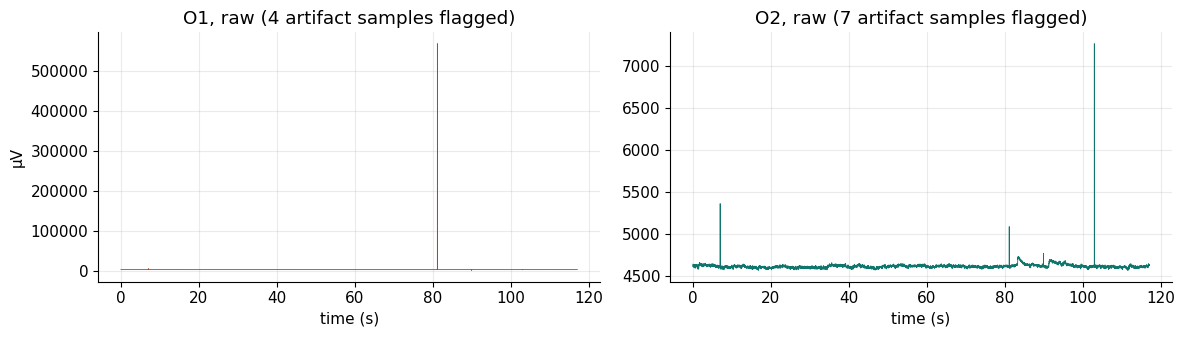

In [ ]:

def clean_channel(x, n_mad=8):
    # Flag samples far from the median (in robust MAD units) as artifacts.
    med = np.median(x)
    mad = np.median(np.abs(x - med)) * 1.4826  # scale MAD to be ~std for Gaussian data
    is_outlier = np.abs(x - med) > n_mad * mad
    return is_outlier

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
o1_raw = df["O1"].values.astype(float)
bad = clean_channel(o1_raw)
ax[0].plot(t, o1_raw, color=TERRACOTTA, lw=0.6)
ax[0].set_title(f"O1, raw ({bad.sum()} artifact samples flagged)")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("\u00b5V")

o2_raw = df["O2"].values.astype(float)
bad2 = clean_channel(o2_raw)
ax[1].plot(t, o2_raw, color=TEAL, lw=0.6)
ax[1].set_title(f"O2, raw ({bad2.sum()} artifact samples flagged)")
ax[1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()



`O2` (right occipital: directly over visual cortex, and the electrode most associated with the
eyes-closed alpha rhythm) is far cleaner than `O1` :  no six-figure sensor-dropout spikes but a
robust outlier check still flags a handful of unusually large samples. We'll interpolate over
just those flagged points (linear interpolation from their neighbors) rather than drop them, so
every downstream index still lines up with the original time axis and eye-state labels.


In [ ]:

def interpolate_outliers(x, n_mad=8):
    # Replace flagged samples with a linear interpolation of their neighbors.
    bad = clean_channel(x, n_mad=n_mad)
    x_clean = x.copy()
    if bad.sum() > 0:
        good_idx = np.where(~bad)[0]
        x_clean[bad] = np.interp(np.where(bad)[0], good_idx, x[good_idx])
    return x_clean, bad.sum()

eye = df["eyeDetection"].values.astype(int)   # 0 = eyes open, 1 = eyes closed
o2_raw_full = df["O2"].values.astype(float)
o2, n_fixed = interpolate_outliers(o2_raw_full)

print(f"O2: interpolated over {n_fixed} flagged samples out of {len(o2)} "
      f"({100*n_fixed/len(o2):.3f}%)")
print(f"{eye.sum()} eyes-closed samples, {len(eye)-eye.sum()} eyes-open samples")


O2: interpolated over 7 flagged samples out of 14980 (0.047%)
6723 eyes-closed samples, 8257 eyes-open samples



---
## 2. Rate of change, on a real signal


Exactly as in the course, we estimate the derivative with a finite difference. Only now on a
real, noisy voltage trace instead of a clean synthetic curve.


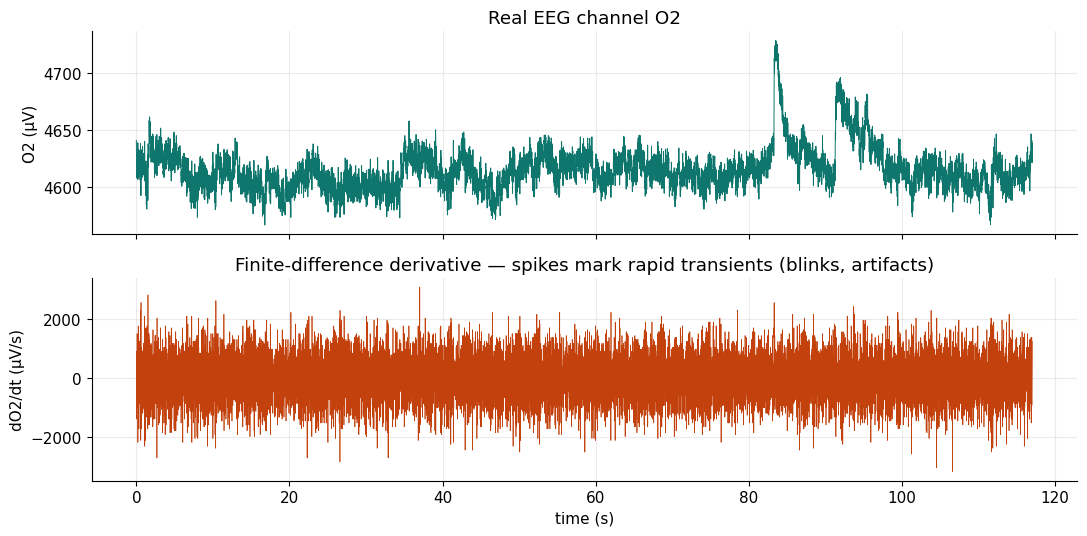

In [ ]:

dO2dt = np.diff(o2) * FS   # finite difference, converted to muV/second
t_mid = (t[:-1] + t[1:]) / 2

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].plot(t, o2, color=TEAL, lw=0.7)
ax[0].set_ylabel("O2 (\u00b5V)"); ax[0].set_title("Real EEG channel O2")
ax[1].plot(t_mid, dO2dt, color=TERRACOTTA, lw=0.5)
ax[1].set_ylabel("dO2/dt (\u00b5V/s)"); ax[1].set_xlabel("time (s)")
ax[1].set_title("Finite-difference derivative \u2014 spikes mark rapid transients (blinks, artifacts)")
plt.tight_layout(); plt.show()



Unlike our clean synthetic curves, the real derivative is dominated by fast, noisy fluctuations
This is normal for scalp EEG, which sums the activity of millions of neurons and picks up muscle
and electrode noise along the way. The *interesting* signal is not in this raw derivative, but in
how the **amplitude** of the fluctuations changes with brain state  which is what we build next.



---
## 3. Building a state variable: the signal envelope

A single EEG sample isn't the quantity that changes with eye state, its *amplitude* is (more
posterior alpha-band power when eyes are closed). We construct a smoothed **envelope**: a rolling
root-mean-square of the (mean-centered) signal over a short window. This becomes our own $V(t)$.


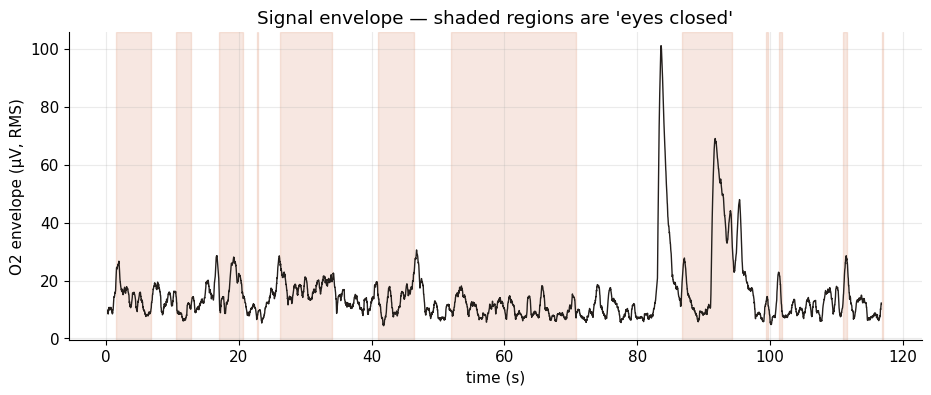

In [ ]:

WIN = 64  # 0.5-second window at 128 Hz
o2_centered = o2 - o2.mean()
envelope = pd.Series(o2_centered ** 2).rolling(WIN, center=True).mean().pow(0.5).values

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, envelope, color=INK, lw=1)

# shade eyes-closed periods
closed = eye == 1
in_closed = False
seg_start = None
for i in range(len(closed)):
    if closed[i] and not in_closed:
        seg_start = t[i]; in_closed = True
    elif not closed[i] and in_closed:
        ax.axvspan(seg_start, t[i], color=TERRACOTTA, alpha=0.12)
        in_closed = False
if in_closed:
    ax.axvspan(seg_start, t[-1], color=TERRACOTTA, alpha=0.12)

ax.set_xlabel("time (s)"); ax.set_ylabel("O2 envelope (\u00b5V, RMS)")
ax.set_title("Signal envelope \u2014 shaded regions are 'eyes closed'")
plt.show()



Even by eye, the envelope tends to sit higher during the shaded (eyes-closed) periods; this is
the real alpha-rhythm effect. Now let's see if we can describe the *transitions* between these
two regimes with our leaky relaxation equation.

> **Try it yourself:** change `WIN` to 32 or 128 and re-run. How does the window size trade off
> noise against how quickly the envelope can track a real transition?



---
## 4. Finding clean transitions

We want moments where the eye state changes *and* stays stable for at least 1.5 seconds on both
sides (so we have a clean "before" and "after" to fit against).


In [ ]:

STABLE = 192  # 1.5 s at 128 Hz

transitions = np.where(np.diff(eye) != 0)[0] + 1
clean_transitions = []
for ti in transitions:
    if ti - STABLE < 0 or ti + STABLE >= len(eye):
        continue
    if np.all(eye[ti - STABLE:ti] == eye[ti - STABLE]) and np.all(eye[ti:ti + STABLE] == eye[ti]):
        clean_transitions.append(ti)

print(f"{len(transitions)} total eye-state changes in the recording")
print(f"{len(clean_transitions)} are 'clean' (stable >=1.5s on both sides) -- these are usable for fitting")
print("Clean transition times (s):", np.round(np.array(clean_transitions) / FS, 2))


23 total eye-state changes in the recording
13 are 'clean' (stable >=1.5s on both sides) -- these are usable for fitting
Clean transition times (s): [ 6.8  10.44 12.8  17.   20.57 26.11 34.   40.97 46.31 51.98 70.73 86.76
 94.34]



---
## 5. Fitting a real relaxation

For each clean transition, we fit the exact relaxation equation from the course:

$$V(t) = V_{eq} + (V_0 - V_{eq})\,e^{-t/\tau}$$

to the real envelope in a window around that transition using `scipy.optimize.curve_fit`
instead of the closed-form solution, since real data needs a numerical fit. We constrain
$\tau$ to a physiologically plausible range (20 ms – 3 s) so the optimizer doesn't wander into
nonsense on noisy data. This is an ordinary, necessary step in real model-fitting.


Best single-transition fit: t=20.57s  (closed->open)
  V0=24.04  V_eq=8.17  tau=602 ms  R2=0.93


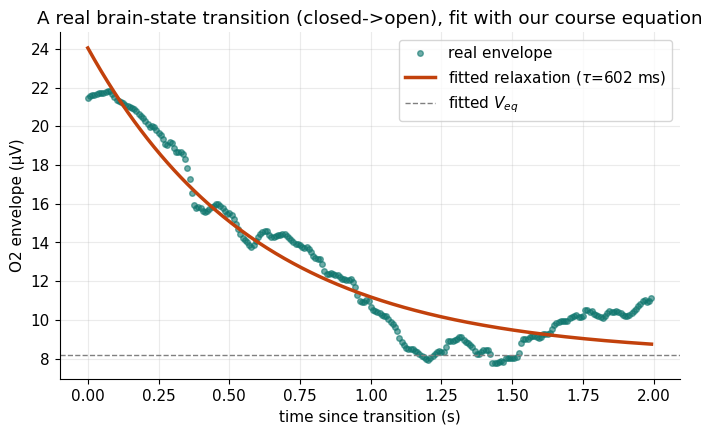

In [ ]:

def relaxation(t, V_eq, V0, tau):
    return V_eq + (V0 - V_eq) * np.exp(-t / tau)

def fit_transition(ti, pre=64, post=192):
    # Fit the relaxation equation to the envelope around one real transition.
    seg = envelope[ti - pre: ti + post]
    tseg = np.arange(len(seg)) / FS
    mask = ~np.isnan(seg)
    tt, vv = tseg[mask], seg[mask]
    p0 = [vv[-10:].mean(), vv[:10].mean(), 0.3]
    popt, _ = curve_fit(relaxation, tt, vv, p0=p0,
                         bounds=([0, 0, 0.02], [200, 200, 3.0]), maxfev=8000)
    pred = relaxation(tt, *popt)
    r2 = 1 - np.sum((vv - pred) ** 2) / np.sum((vv - vv.mean()) ** 2)
    return {"t_transition": ti / FS, "ti": ti, "V_eq": popt[0], "V0": popt[1], "tau": popt[2],
            "r2": r2, "tt": tt, "vv": vv, "pred": pred,
            "direction": "closed->open" if eye[ti] == 0 else "open->closed"}

fits = [fit_transition(ti) for ti in clean_transitions]
best = max(fits, key=lambda f: f["r2"])

print(f"Best single-transition fit: t={best['t_transition']:.2f}s  ({best['direction']})")
print(f"  V0={best['V0']:.2f}  V_eq={best['V_eq']:.2f}  tau={best['tau']*1000:.0f} ms  R2={best['r2']:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(best["tt"], best["vv"], "o", color=TEAL, ms=4, alpha=0.6, label="real envelope")
ax.plot(best["tt"], best["pred"], "-", color=TERRACOTTA, lw=2.5,
        label=f"fitted relaxation ($\\tau$={best['tau']*1000:.0f} ms)")
ax.axhline(best["V_eq"], color="gray", ls="--", lw=1, label="fitted $V_{eq}$")
ax.set_xlabel("time since transition (s)"); ax.set_ylabel("O2 envelope (\u00b5V)")
ax.set_title(f"A real brain-state transition ({best['direction']}), fit with our course equation")
ax.legend(); plt.show()



This is a genuinely encouraging result: the same one-parameter relaxation equation we derived
from first principles for membrane potential fits a real, physiologically completely different
signal, scalp-recorded, population-level EEG  reasonably well. That's not a coincidence; it's
the leaky-dynamics pattern from Section 7 showing up again, exactly as promised: *"once you start
looking, you will find this pattern is genuinely everywhere."*

But one good fit could be luck. Let's check **all** the clean transitions.



---
## 6. Does it hold up? Aggregating across every transition

Real science doesn't trust a single fit — we check whether the pattern holds across all the
clean examples we found.


In [ ]:

results = pd.DataFrame([{
    "t": f["t_transition"], "direction": f["direction"],
    "V0": f["V0"], "V_eq": f["V_eq"], "tau_ms": f["tau"] * 1000, "R2": f["r2"],
} for f in fits])
results.round(2)


,t,direction,V0,V_eq,tau_ms,R2
0,6.80,closed->open,5.16,17.62,464.38,0.68
1,10.44,open->closed,16.30,0.00,1975.49,0.76
2,12.80,closed->open,12.31,9.57,2810.53,0.08
3,17.00,open->closed,32.96,11.25,398.40,0.77
4,20.57,closed->open,24.04,8.17,601.74,0.93
5,26.11,open->closed,26.78,5.09,3000.00,0.47
6,34.00,closed->open,22.30,3.37,2820.81,0.56
7,40.97,open->closed,22.57,7.37,545.58,0.65
8,46.31,closed->open,13.47,23.27,221.02,0.23
9,51.98,open->closed,7.89,25.55,3000.00,0.66


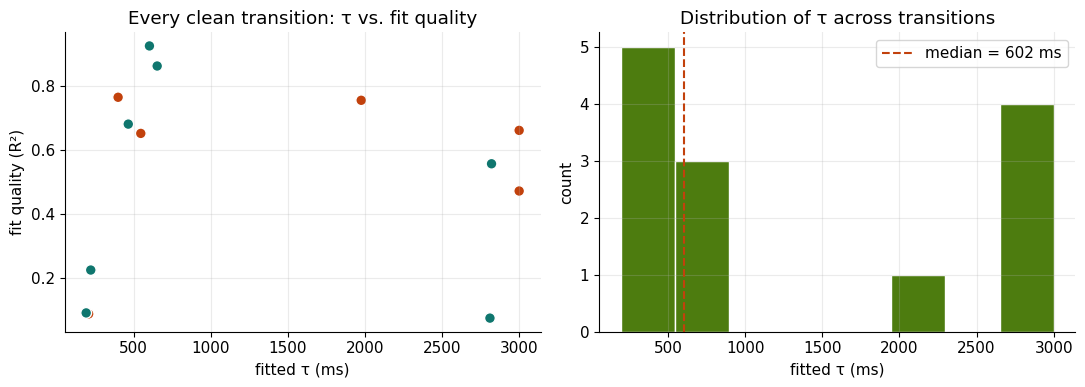

Median tau = 602 ms   (IQR: 398-2811 ms)
Median R2 = 0.65


In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = results["direction"].map({"closed->open": TEAL, "open->closed": TERRACOTTA})
ax[0].scatter(results["tau_ms"], results["R2"], c=colors, s=60, edgecolor="white")
ax[0].set_xlabel("fitted \u03c4 (ms)"); ax[0].set_ylabel("fit quality (R\u00b2)")
ax[0].set_title("Every clean transition: \u03c4 vs. fit quality")

ax[1].hist(results["tau_ms"], bins=8, color=OLIVE, edgecolor="white")
ax[1].axvline(results["tau_ms"].median(), color=TERRACOTTA, ls="--",
              label=f"median = {results['tau_ms'].median():.0f} ms")
ax[1].set_xlabel("fitted \u03c4 (ms)"); ax[1].set_ylabel("count")
ax[1].set_title("Distribution of \u03c4 across transitions"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Median tau = {results['tau_ms'].median():.0f} ms   "
      f"(IQR: {results['tau_ms'].quantile(.25):.0f}-{results['tau_ms'].quantile(.75):.0f} ms)")
print(f"Median R2 = {results['R2'].median():.2f}")



This is what real data honestly looks like: some transitions fit the relaxation model very well
(R² above 0.8), others fit poorly (R² near zero)
A a single 2-minute recording from one person
contains real trial-to-trial variability (attention lapses, partial blinks, muscle artifacts).
The **median** τ across transitions (rather than any single fit) is the more trustworthy summary
exactly the aggregate-over-many-trials logic that real neuroscience analysis relies on.

> **Try it yourself:** split `results` by `direction` and compare median τ for "closed→open" vs.
> "open→closed" separately. Does one direction relax faster than the other?



---
## 7. Two equilibria, two brain states


Rather than trusting individual fitted $V_{eq}$ values (noisy on short segments), we estimate
each state's equilibrium directly and robustly: the **mean envelope value during long, stable
stretches** of each condition, well away from any transition.


In [ ]:

# "Stable" = at least 1s into a state and at least 1s before it ends
def stable_mask(eye_vec, margin=128):
    m = np.zeros_like(eye_vec, dtype=bool)
    change_idx = np.where(np.diff(eye_vec) != 0)[0]
    boundaries = np.concatenate([[0], change_idx + 1, [len(eye_vec)]])
    for i in range(len(boundaries) - 1):
        s, e = boundaries[i], boundaries[i + 1]
        core_s, core_e = s + margin, e - margin
        if core_e > core_s:
            m[core_s:core_e] = True
    return m

stable = stable_mask(eye)
open_mask = stable & (eye == 0)
closed_mask = stable & (eye == 1)

V_eq_open = np.nanmean(envelope[open_mask])
V_eq_closed = np.nanmean(envelope[closed_mask])
sigma_open = np.nanstd(envelope[open_mask])
sigma_closed = np.nanstd(envelope[closed_mask])

print(f"Eyes OPEN    equilibrium: V_eq = {V_eq_open:.2f} +/- {sigma_open:.2f} uV   (n={open_mask.sum()} stable samples)")
print(f"Eyes CLOSED  equilibrium: V_eq = {V_eq_closed:.2f} +/- {sigma_closed:.2f} uV   (n={closed_mask.sum()} stable samples)")


Eyes OPEN    equilibrium: V_eq = 14.51 +/- 13.13 uV   (n=5304 stable samples)
Eyes CLOSED  equilibrium: V_eq = 14.76 +/- 10.97 uV   (n=4716 stable samples)


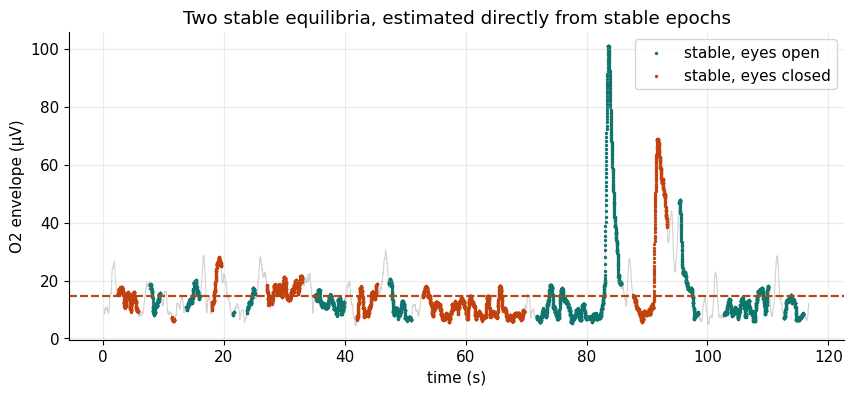

In [ ]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, envelope, color="lightgray", lw=0.8, zorder=1)
ax.scatter(t[open_mask], envelope[open_mask], s=2, color=TEAL, label="stable, eyes open")
ax.scatter(t[closed_mask], envelope[closed_mask], s=2, color=TERRACOTTA, label="stable, eyes closed")
ax.axhline(V_eq_open, color=TEAL, ls="--", lw=1.5)
ax.axhline(V_eq_closed, color=TERRACOTTA, ls="--", lw=1.5)
ax.set_xlabel("time (s)"); ax.set_ylabel("O2 envelope (\u00b5V)")
ax.set_title("Two stable equilibria, estimated directly from stable epochs")
ax.legend(); plt.show()



---
## 8. A calibrated stochastic model


We build a simulation using **only numbers estimated from the real recording**. If our simple model captures anything genuine, a simulated
trajectory built this way should *resemble* — not equal, but resemble  the real one.


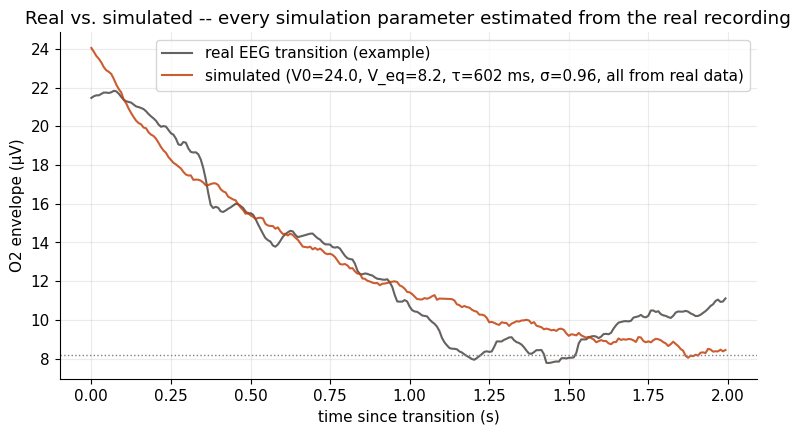

In [ ]:

def euler_maruyama_relaxation(V0, V_eq, tau, sigma, T, dt, rng):
    # adding noise with euler's method
    n = int(T / dt)
    V = np.zeros(n)
    V[0] = V0
    for i in range(1, n):
        dV = -(V[i - 1] - V_eq) / tau
        noise = sigma * rng.standard_normal() * np.sqrt(dt)
        V[i] = V[i - 1] + dV * dt + noise
    return V

# Calibrate locally, around our best example transition  not from the diluted
# whole-session averages computed in Section 7.
ti_example = best["ti"]
local_sigma = np.nanstd(envelope[ti_example + 64: ti_example + 192])  # settled, post-transition
tau_median = results["tau_ms"].median() / 1000  # seconds
dt_sim = 1 / FS
T_sim = 2.0

rng = np.random.default_rng(0)
sim = euler_maruyama_relaxation(best["V0"], best["V_eq"], tau_median, local_sigma, T_sim, dt_sim, rng)
t_sim = np.arange(len(sim)) * dt_sim

real_seg = envelope[ti_example - 64: ti_example + 192]
t_real = np.arange(len(real_seg)) / FS

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_real, real_seg, color=INK, lw=1.5, alpha=0.7, label="real EEG transition (example)")
ax.plot(t_sim, sim, color=TERRACOTTA, lw=1.5, alpha=0.85,
        label=f"simulated (V0={best['V0']:.1f}, V_eq={best['V_eq']:.1f}, "
              f"\u03c4={tau_median*1000:.0f} ms, \u03c3={local_sigma:.2f}, all from real data)")
ax.axhline(best["V_eq"], color="gray", ls=":", lw=1)
ax.set_xlabel("time since transition (s)"); ax.set_ylabel("O2 envelope (\u00b5V)")
ax.set_title("Real vs. simulated -- every simulation parameter estimated from the real recording")
ax.legend(); plt.show()



The simulated trace won't overlay the real one point-for-point. What we're
checking is whether it's *the same kind of thing*: relaxing at a similar rate, settling around a
similar target, fluctuating with a similar roughness. That qualitative resemblance, built from
four numbers pulled directly out of a real, messy recording, is the actual payoff of the course's
toolkit — not that it perfectly predicts a brain, but that it gives you a small, interpretable
model whose parameters mean something you can check against data.

> **Try it yourself:** run the simulation cell above a few times with different `rng` seeds.
> Then generate 20 simulated traces and compare the *spread* at, say, t=1s to the spread across
> our real fitted `V0` values in `results`. Are they roughly the same order of magnitude?
